# Week 3 · Notebook 3 — Iterated Local Search, Variable Neighbourhood Search and GRASP

**Goals**
- Build a fast, validated local-search engine for the TSP: vectorised best-improvement **2-opt** and **Or-opt**
  deltas, combined in a **Variable Neighbourhood Descent** (VND).
- Implement three classic ways of *re-using* a local search:
  **Iterated Local Search** (ILS; Lourenço, Martin & Stützle 2003) with the double-bridge kick and several
  acceptance criteria; **Variable Neighbourhood Search** (VNS; Mladenović & Hansen 1997) with shaking in a
  sequence of increasingly disruptive neighbourhoods $N_1, N_2, \dots, N_{k_{max}}$; **GRASP** (Feo & Resende 1989, 1995) with a restricted candidate
  list controlled by $\alpha$.
- Validate all three against the exact Held–Karp optimum on small instances, then study perturbation strength,
  acceptance, the GRASP $\alpha$ trade-off, and compare the three at an equal evaluation budget on $n = 100$.

**Prerequisites:** Week 1 (2-opt, local optima, TSP), Notebooks 1–2 (trajectory methods, memory).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import time
from utils import random_euclidean_tsp, tour_length, held_karp, best_so_far_on_grid, bhh_constant_estimate, PALETTE
from scipy.stats import binomtest

## 1. Three ways to restart a local search

Let $LS: S \to S$ map a solution to a local optimum. The set of local optima $S^{\ast} = LS(S)$ is much smaller than
$S$; all three methods of this notebook are *searches over $S^{\ast}$* that differ in how they generate the next
starting point.

| | generation of next start | acceptance | memory | key parameter |
|---|---|---|---|---|
| **ILS** | perturb the current local optimum ("kick") | better / random walk / Metropolis / restart | current (+ best) | kick strength |
| **VNS** | random point of $N_k(x)$, $k$ grows on failure, resets on success | better only | current, $k$ | $k_{max}$ and the $N_k$ |
| **GRASP** | fresh *greedy randomised* construction | independent iterations | best only | RCL parameter $\alpha$ |

```text
ILS:   x <- LS(x0)                      VNS:  x <- LS(x0); k <- 1              GRASP: repeat:
       repeat:                                repeat:                                 x <- GreedyRandomised(alpha)
         y <- LS(Perturb(x))                    y <- LS(Shake(x, N_k))                x <- LS(x)
         x <- Accept(x, y)                      if f(y) < f(x): x <- y; k <- 1         keep the best
                                                else: k <- k+1 (k > kmax -> k <- 1)
```

**History.** ILS gathers ideas going back to *large-step Markov chains* (Martin, Otto & Felten 1991, who introduced
the double-bridge kick) and *iterated Lin–Kernighan* (Johnson 1990); the unifying framework is Lourenço, Martin &
Stützle, *Iterated Local Search* (Handbook of Metaheuristics, 2003). VNS was introduced by Mladenović & Hansen
(Computers & OR, 1997). GRASP was introduced by Feo & Resende (Operations Research Letters, 1989) and surveyed in
J. Global Optimization (1995).

## 2. Local-search engine: 2-opt and Or-opt with vectorised deltas

Tour $t = (t_0, \dots, t_{n-1})$, $D$ symmetric. **2-opt** move $(i,j)$, $i \lt j$: reverse $t_{i+1..j}$, replacing edges
$(t_i,t_{i+1})$ and $(t_j,t_{j+1})$ by $(t_i,t_j)$ and $(t_{i+1},t_{j+1})$:

$$
\Delta_{ij} = D_{t_i t_j} + D_{t_{i+1} t_{j+1}} - D_{t_i t_{i+1}} - D_{t_j t_{j+1}}
$$

(indices mod $n$; the $n(n-3)/2$ valid pairs exclude adjacent edges). **Or-opt** (Or, 1976) moves a segment of
$L \in \lbrace 1,2,3 \rbrace$ consecutive cities $t_i \dots t_{i+L-1}$ (first $u$, last $v$, neighbours $p$, $q$) between
$t_j$ and $t_{j+1}$, optionally reversed:

$$
\Delta = \underbrace{D_{t_j u} + D_{v t_{j+1}} - D_{t_j t_{j+1}}}_{\text{insert (forward)}}
- \underbrace{(D_{p u} + D_{v q} - D_{p q})}_{\text{removal gain}}.
$$

Both are computed for *all* moves at once as $n \times n$ arrays. Each examined move counts as one evaluation.
**VND** (Mladenović & Hansen) descends with $N_1$ = 2-opt until no improvement, then tries $N_2$ = Or-opt, and
returns to $N_1$ after every success; its result is locally optimal for *both* neighbourhoods.

In [2]:
class Counter:
    """Counts neighbour evaluations (one per examined move or construction candidate)."""
    def __init__(self):
        self.evals = 0


def two_opt_mask(n):
    I, J = np.indices((n, n))
    m = J >= I + 2
    m[0, n - 1] = False
    return m


def two_opt_deltas(t, D):
    a, b = t, np.roll(t, -1)
    dab = D[a, b]
    return D[a[:, None], a[None, :]] + D[b[:, None], b[None, :]] - dab[:, None] - dab[None, :]


def apply_two_opt(t, i, j):
    t = t.copy()
    t[i + 1:j + 1] = t[i + 1:j + 1][::-1]
    return t


def or_opt_deltas(t, D, L):
    """Forward and reversed insertion deltas for every segment start i and insertion edge j, plus validity mask."""
    n = len(t)
    pos = np.arange(n)
    prev, first = t[(pos - 1) % n], t
    last, nxt = t[(pos + L - 1) % n], t[(pos + L) % n]
    gain = D[prev, first] + D[last, nxt] - D[prev, nxt]
    tj, tj1 = t, np.roll(t, -1)
    base = -D[tj, tj1]
    fwd = D[tj[None, :], first[:, None]] + D[last[:, None], tj1[None, :]] + base[None, :] - gain[:, None]
    rev = D[tj[None, :], last[:, None]] + D[first[:, None], tj1[None, :]] + base[None, :] - gain[:, None]
    valid = ((pos[None, :] - (pos[:, None] - 1)) % n) > L        # edge j must not touch the segment
    return fwd, rev, valid


def apply_or_opt(t, i, j, L, rev):
    n = len(t)
    idx = (i + np.arange(L)) % n
    seg = t[idx][::-1] if rev else t[idx]
    keep = np.ones(n, bool); keep[idx] = False
    rest = t[keep]
    k = int(np.flatnonzero(rest == t[j])[0])
    return np.concatenate([rest[:k + 1], seg, rest[k + 1:]])


def vnd(t, D, cnt, mask, tol=1e-10):
    """Best-improvement VND over N1 = 2-opt, N2 = Or-opt (L = 1, 2, 3, both orientations)."""
    t = np.array(t)
    length = tour_length(t, D)
    n_valid = int(mask.sum())
    while True:
        M = np.where(mask, two_opt_deltas(t, D), np.inf)
        cnt.evals += n_valid
        k = int(np.argmin(M))
        if M.flat[k] < -tol:
            i, j = divmod(k, len(t))
            t = apply_two_opt(t, i, j); length += M.flat[k]
            continue
        best = (0.0, None)
        for L in (1, 2, 3):
            fwd, rev, valid = or_opt_deltas(t, D, L)
            cnt.evals += 2 * int(valid.sum())
            for rv, A in ((False, fwd), (True, rev)):
                A = np.where(valid, A, np.inf)
                kk = int(np.argmin(A))
                if A.flat[kk] < best[0] - tol:
                    best = (A.flat[kk], (kk // len(t), kk % len(t), L, rv))
        if best[1] is None:
            return t, length
        t = apply_or_opt(t, *best[1]); length += best[0]

### Validation of the move deltas and of VND

Every delta is compared with `tour_length` of the explicitly modified tour (an independent $O(n)$ computation),
for all 2-opt moves and all Or-opt moves of a random 30-city tour.

In [3]:
pts30, D30 = random_euclidean_tsp(30, rng)
t = rng.permutation(30)
L0 = tour_length(t, D30)
m30 = two_opt_mask(30)
M = two_opt_deltas(t, D30)
err2 = max(abs(M[i, j] - (tour_length(apply_two_opt(t, i, j), D30) - L0)) for i, j in zip(*np.nonzero(m30)))
check_close(err2, 0.0, f"2-opt deltas, all {m30.sum()} moves vs recomputation (max abs error)", atol=1e-10)
erro, n_or = 0.0, 0
for L in (1, 2, 3):
    fwd, rev, valid = or_opt_deltas(t, D30, L)
    for i, j in zip(*np.nonzero(valid)):
        for rv, A in ((False, fwd), (True, rev)):
            new = apply_or_opt(t, i, j, L, rv)
            assert sorted(new) == list(range(30))
            erro = max(erro, abs(A[i, j] - (tour_length(new, D30) - L0))); n_or += 1
check_close(erro, 0.0, f"Or-opt deltas, all {n_or} moves vs recomputation (max abs error)", atol=1e-10)
c = Counter()
tv, Lv = vnd(t, D30, c, m30)
check_close(Lv, tour_length(tv, D30), "VND: incrementally tracked length = recomputed length", atol=1e-9)
Mv = np.where(m30, two_opt_deltas(tv, D30), np.inf)
check_true(Mv.min() > -1e-10 and all(np.where(or_opt_deltas(tv, D30, L)[2], np.minimum(*or_opt_deltas(tv, D30, L)[:2]),
                                               np.inf).min() > -1e-10 for L in (1, 2, 3)),
           "VND output is a local optimum for both 2-opt and Or-opt")

[PASS] 2-opt deltas, all 405 moves vs recomputation (max abs error): got 0.0, expected 0.0


[PASS] Or-opt deltas, all 4860 moves vs recomputation (max abs error): got 0.0, expected 0.0
[PASS] VND: incrementally tracked length = recomputed length: got 4.744866, expected 4.744866
[PASS] VND output is a local optimum for both 2-opt and Or-opt


## 3. The double-bridge kick

Cut the tour into four non-empty segments $A B C D$ and reconnect them as $A\,D\,C\,B$ **without reversing any
segment**. The four edges between consecutive segments are removed and replaced by: end of $A$ → start of $D$,
end of $D$ → start of $C$, end of $C$ → start of $B$, end of $B$ → start of $A$. Written as two "bridge" 2-changes,
each of which alone would split the tour into two cycles, this is the double bridge of Martin, Otto & Felten
(1991); after rotating the labels it can equally be written $B\,A\,D\,C$, and read backwards it equals
$A^r B^r C^r D^r$ (every segment reversed in place). It is a *non-sequential* 4-change, which
is why 2-opt, 3-opt and Lin–Kernighan cannot easily undo it.

*Careful:* the segment exchange $A\,C\,B\,D$ (in array form `t[:a] + t[b:c] + t[a:b] + t[c:]`), which many texts
and code snippets call "the double bridge", keeps the edge from the end of $D$ back to the start of $A$ and
therefore changes only **three** edges: it is the pure (no-reversal) 3-opt move, i.e. an Or-opt-type segment
move, which a 3-opt local search can undo in one step.

One more subtlety: a new edge coincides with an old one when the two segments it joins are both single cities
(e.g. if $C$ and $D$ are singletons, "end of $D$ → start of $C$" is the old $C$–$D$ edge). Exactly, the double
bridge changes $4 - s$ edges and $A\,C\,B\,D$ changes $3 - [\vert B \vert = \vert C \vert = 1]$, where $s$ is the number
of cyclically adjacent segment pairs $(A,B), (B,C), (C,D), (D,A)$ that are both singletons. We verify both
formulas on random cuts of tours of every size from 5 to 40 (so singleton segments really occur).

A kick of strength $k$ applies $k$ random double bridges. The kick must be strong enough that the local search does
not simply undo it, and weak enough that the new local optimum shares most of its structure with the old one.

In [4]:
def double_bridge(t, rng, k=1):
    n = len(t)
    for _ in range(k):
        a, b, c = np.sort(rng.choice(np.arange(1, n), 3, replace=False))
        t = np.concatenate([t[:a], t[c:], t[b:c], t[a:b]])          # A D C B
    return t


def edge_set(t):
    return {frozenset((int(u), int(v))) for u, v in zip(t, np.roll(t, -1))}

ok4, ok3, n_cuts, n_single, big4, big3 = True, True, 0, 0, set(), set()
for n_db in range(5, 41):
    t = rng.permutation(n_db)
    for _ in range(60):
        a, b, c_ = np.sort(rng.choice(np.arange(1, n_db), 3, replace=False))
        lens = np.array([a, b - a, c_ - b, n_db - c_])              # |A|, |B|, |C|, |D|
        single = lens == 1
        s_adj = int(np.sum(single & np.roll(single, -1)))          # adjacent singleton pairs (A,B),(B,C),(C,D),(D,A)
        adcb = np.concatenate([t[:a], t[c_:], t[b:c_], t[a:b]])
        acbd = np.concatenate([t[:a], t[b:c_], t[a:b], t[c_:]])
        ch4 = len(edge_set(t) - edge_set(adcb)); ch3 = len(edge_set(t) - edge_set(acbd))
        ok4 &= ch4 == 4 - s_adj
        ok3 &= ch3 == 3 - int(single[1] and single[2])
        n_cuts += 1; n_single += s_adj > 0
        if lens.min() >= 2:
            big4.add(ch4); big3.add(ch3)
print(f"{n_cuts} random cuts, {n_single} of them with adjacent singleton segments")
check_true(ok4, "double bridge A D C B changes exactly 4 - s edges on every cut")
check_true(ok3, "segment exchange A C B D changes exactly 3 - [|B| = |C| = 1] edges on every cut")
check_true(big4 == {4} and big3 == {3}, "with all segments of length >= 2: A D C B changes 4 edges, A C B D only 3")
t = rng.permutation(50)
check_true(sorted(double_bridge(t, rng, 3)) == list(range(50)), "k-fold double bridge returns a permutation")

2160 random cuts, 322 of them with adjacent singleton segments
[PASS] double bridge A D C B changes exactly 4 - s edges on every cut
[PASS] segment exchange A C B D changes exactly 3 - [|B| = |C| = 1] edges on every cut
[PASS] with all segments of length >= 2: A D C B changes 4 edges, A C B D only 3
[PASS] k-fold double bridge returns a permutation


## 4. ILS, VNS and GRASP

All three use the same VND and the same evaluation counter; each records (evaluations, best length) after every
local search, so results are read off at **exactly** the same budget with `best_so_far_on_grid`.

*ILS acceptance criteria* (Lourenço et al. 2003): **Better** (accept $y$ iff $f(y) \lt f(x)$; strong intensification),
**RW** (random walk, always accept; strong diversification), **LSMC** (accept worse with probability
$e^{-(f(y)-f(x))/T}$, the "large-step Markov chain" of Martin, Otto & Felten) and **Restart** (the kick is a
brand-new random tour — ILS degenerates to random-restart local search).

*VNS shaking:* $N_k(x)$ = tours reachable by $k$ random double bridges, $k = 1, \dots, k_{max}$. These sets are
increasingly disruptive but not nested by construction: the inverse of a double bridge is again a double bridge,
which gives $N_k \supseteq N_{k-2}$, but $N_{k-1} \subseteq N_k$ is not guaranteed. VNS does not need nesting,
only a sequence of neighbourhoods ordered by strength.

*GRASP construction:* nearest-neighbour style. From the current city with unvisited candidates of cost
$c(j) = D_{\text{cur}, j}$, the **restricted candidate list** is
$RCL = \lbrace j : c(j) \le c_{min} + \alpha (c_{max} - c_{min}) \rbrace$ and the next city is drawn uniformly from it:
$\alpha = 0$ is pure greedy (nearest neighbour, random only through ties and the start city), $\alpha = 1$ is a
uniformly random tour. Each candidate cost examined counts as one evaluation.

In [5]:
def ils(D, budget, rng, k=1, accept="better", T=None, x0=None):
    n = len(D); cnt = Counter(); mask = two_opt_mask(n)
    x, fx = vnd(rng.permutation(n) if x0 is None else x0, D, cnt, mask)
    best, best_x = fx, x.copy()
    ev, bs, revert = [cnt.evals], [best], []
    while cnt.evals < budget:
        start = rng.permutation(n) if accept == "restart" else double_bridge(x, rng, k)
        y, fy = vnd(start, D, cnt, mask)
        revert.append(abs(fy - fx) < 1e-9)
        if fy < best - 1e-12:
            best, best_x = fy, y.copy()
        if (accept in ("better", "restart") and fy < fx - 1e-12) or accept == "rw" or \
           (accept == "lsmc" and (fy < fx or rng.random() < np.exp(-(fy - fx) / T))):
            x, fx = y, fy
        ev.append(cnt.evals); bs.append(best)
    return dict(best=best, tour=best_x, ev=np.array(ev), bs=np.array(bs), revert=np.mean(revert))


def vns(D, budget, rng, kmax=5):
    n = len(D); cnt = Counter(); mask = two_opt_mask(n)
    x, fx = vnd(rng.permutation(n), D, cnt, mask)
    ev, bs, k, ks = [cnt.evals], [fx], 1, []
    while cnt.evals < budget:
        y, fy = vnd(double_bridge(x, rng, k), D, cnt, mask)
        ks.append(k)
        if fy < fx - 1e-12:
            x, fx, k = y, fy, 1
        else:
            k = k + 1 if k < kmax else 1
        ev.append(cnt.evals); bs.append(fx)
    return dict(best=fx, tour=x, ev=np.array(ev), bs=np.array(bs), ks=np.array(ks))


def grasp_construct(D, alpha, rng, cnt):
    n = len(D)
    tour = [int(rng.integers(n))]
    unvisited = np.ones(n, bool); unvisited[tour[0]] = False
    for _ in range(n - 1):
        cand = np.flatnonzero(unvisited)
        c = D[tour[-1], cand]
        cnt.evals += len(cand)
        rcl = cand[c <= c.min() + alpha * (c.max() - c.min()) + 1e-12]
        nxt = int(rng.choice(rcl))
        tour.append(nxt); unvisited[nxt] = False
    return np.array(tour)


def grasp(D, budget, rng, alpha=0.2):
    n = len(D); cnt = Counter(); mask = two_opt_mask(n)
    best, best_x = np.inf, None
    ev, bs, built, polished = [], [], [], []
    while cnt.evals < budget:
        x = grasp_construct(D, alpha, rng, cnt)
        built.append(tour_length(x, D))
        x, fx = vnd(x, D, cnt, mask)
        polished.append(fx)
        if fx < best:
            best, best_x = fx, x
        ev.append(cnt.evals); bs.append(best)
    return dict(best=best, tour=best_x, ev=np.array(ev), bs=np.array(bs),
                built=np.array(built), polished=np.array(polished))


def at_budget(res, budget):
    """Best-so-far length after exactly `budget` evaluations (only local searches completed within it count)."""
    return float(best_so_far_on_grid(res["ev"], res["bs"], np.array([budget]))[0])

### Validation against Held–Karp

Four random Euclidean instances with $n = 11$ are solved exactly by Held–Karp dynamic programming
($O(n^2 2^n)$). Each method runs from 5 seeds with a budget of $10^5$ evaluations. We also check that
every returned tour is a permutation whose recomputed length equals the reported one.

In [6]:
t0 = time.time()
hk_hits = {"ILS": 0, "VNS": 0, "GRASP": 0}
ok = True
for inst in range(4):
    _, Dh = random_euclidean_tsp(11, np.random.default_rng(40 + inst))
    opt, opt_tour = held_karp(Dh)
    assert abs(tour_length(opt_tour, Dh) - opt) < 1e-9
    for sd in range(5):
        for name, fn in [("ILS", lambda g: ils(Dh, 100_000, g)), ("VNS", lambda g: vns(Dh, 100_000, g)),
                         ("GRASP", lambda g: grasp(Dh, 100_000, g, alpha=0.3))]:
            r = fn(np.random.default_rng(sd))
            ok &= sorted(r["tour"]) == list(range(11)) and abs(tour_length(r["tour"], Dh) - r["best"]) < 1e-9
            hk_hits[name] += abs(r["best"] - opt) < 1e-9
print({k: f"{v}/20" for k, v in hk_hits.items()}, f"({time.time() - t0:.1f} s)")
check_true(ok, "all returned tours are permutations with correctly reported lengths")
check_true(all(v == 20 for v in hk_hits.values()), "ILS, VNS and GRASP all reach the Held-Karp optimum on every run")

{'ILS': '20/20', 'VNS': '20/20', 'GRASP': '20/20'} (19.7 s)
[PASS] all returned tours are permutations with correctly reported lengths
[PASS] ILS, VNS and GRASP all reach the Held-Karp optimum on every run


## 5. ILS: perturbation strength and acceptance ($n = 100$)

Budget $10^7$ evaluations per run, 2 instances × 3 seeds. For each setting we also measure the **revert rate**:
the fraction of kicks after which VND returns to a local optimum of exactly the same length as the current one —
i.e. the kick was wasted.

In [7]:
t0 = time.time()
B = 10_000_000
inst100 = [random_euclidean_tsp(100, np.random.default_rng(1000 + i))[1] for i in range(2)]
settings = [("k=1, better", dict(k=1)), ("k=2, better", dict(k=2)), ("k=4, better", dict(k=4)),
            ("k=8, better", dict(k=8)), ("restart", dict(accept="restart")),
            ("k=2, RW", dict(k=2, accept="rw")), ("k=2, LSMC", dict(k=2, accept="lsmc", T=0.02))]
S_len, S_rev = np.zeros((len(settings), 6)), np.zeros((len(settings), 6))
for a, (name, kw) in enumerate(settings):
    for i, Dm in enumerate(inst100):
        for sd in range(3):
            r = ils(Dm, B, np.random.default_rng(sd), **kw)
            S_len[a, 3 * i + sd], S_rev[a, 3 * i + sd] = at_budget(r, B), r["revert"]
ref = np.repeat(S_len.reshape(len(settings), 2, 3).min(axis=(0, 2)), 3)
S_gap = 100 * (S_len - ref) / ref
for (name, _), g, rv in zip(settings, S_gap, S_rev):
    print(f"{name:>12}: median gap {np.median(g):5.2f}%  IQR [{np.percentile(g, 25):5.2f}, {np.percentile(g, 75):5.2f}]"
          f"   revert rate {rv.mean():.2f}")
print(f"({time.time() - t0:.1f} s)")
check_true(S_rev[0].mean() > S_rev[3].mean(), "weak kicks (k=1) are undone by VND more often than strong kicks (k=8)")

 k=1, better: median gap  3.16%  IQR [ 1.93,  3.96]   revert rate 0.98
 k=2, better: median gap  1.42%  IQR [ 0.26,  2.50]   revert rate 0.94
 k=4, better: median gap  1.16%  IQR [ 0.49,  1.26]   revert rate 0.78
 k=8, better: median gap  0.85%  IQR [ 0.36,  1.04]   revert rate 0.50
     restart: median gap  1.80%  IQR [ 1.23,  2.28]   revert rate 0.00
     k=2, RW: median gap  1.71%  IQR [ 1.16,  2.53]   revert rate 0.90
   k=2, LSMC: median gap  1.40%  IQR [ 0.68,  2.66]   revert rate 0.89
(50.7 s)
[PASS] weak kicks (k=1) are undone by VND more often than strong kicks (k=8)


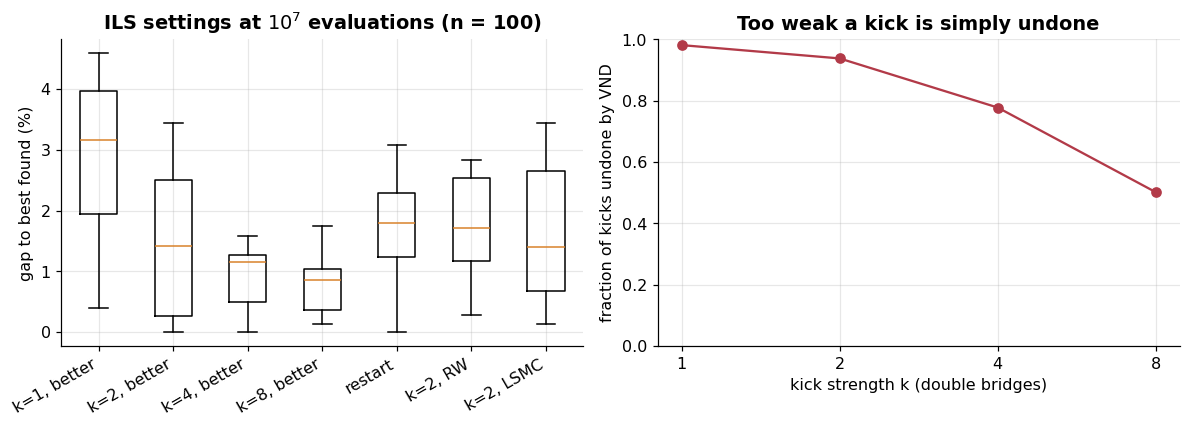

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.boxplot(list(S_gap), tick_labels=[s[0] for s in settings], widths=0.5)
ax.set_ylabel("gap to best found (%)"); ax.set_title("ILS settings at $10^7$ evaluations (n = 100)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax = axes[1]
ks_ = [1, 2, 4, 8]
ax.plot(ks_, S_rev[:4].mean(1), "o-", color=PALETTE["red"], label="revert rate")
ax.set_xscale("log", base=2); ax.set_xticks(ks_, [str(k) for k in ks_])
ax.set_xlabel("kick strength k (double bridges)"); ax.set_ylabel("fraction of kicks undone by VND")
ax.set_title("Too weak a kick is simply undone"); ax.set_ylim(0, 1)
fig.tight_layout()
savefig("w3_ils_strength_acceptance.png"); plt.show()

## 6. GRASP: the $\alpha$ trade-off

Small $\alpha$ builds good but similar tours (little diversity, and VND has little left to do); large $\alpha$ builds
poor, diverse tours that cost many VND evaluations to repair. We record, for each $\alpha$, the mean constructed
length, the mean length after VND, the number of GRASP iterations that fit in the budget and the best length at
the budget (2 instances × 3 seeds, $10^7$ evaluations).

In [9]:
t0 = time.time()
alphas = [0.0, 0.1, 0.2, 0.5, 1.0]
G_best, G_built, G_pol, G_it = (np.zeros((len(alphas), 6)) for _ in range(4))
for a, al in enumerate(alphas):
    for i, Dm in enumerate(inst100):
        for sd in range(3):
            r = grasp(Dm, B, np.random.default_rng(sd), alpha=al)
            j = 3 * i + sd
            G_best[a, j], G_built[a, j], G_pol[a, j], G_it[a, j] = at_budget(r, B), r["built"].mean(), \
                r["polished"].mean(), np.sum(r["ev"] <= B)
refG = np.minimum(np.repeat(G_best.reshape(len(alphas), 2, 3).min(axis=(0, 2)), 3), ref)
for a, al in enumerate(alphas):
    print(f"alpha={al:3.1f}: built {G_built[a].mean():6.2f}  after VND {G_pol[a].mean():5.2f}  "
          f"iterations {G_it[a].mean():5.1f}  best gap {np.median(100 * (G_best[a] - refG) / refG):5.2f}% (median)")
print(f"({time.time() - t0:.1f} s)")
check_true(np.all(np.diff(G_built.mean(1)) > 0), "constructed tours get longer as alpha grows")
check_true(G_it[0].mean() > G_it[-1].mean(), "greedier construction leaves budget for more GRASP iterations")

alpha=0.0: built   9.70  after VND  7.81  iterations  28.7  best gap  1.06% (median)
alpha=0.1: built  12.54  after VND  7.89  iterations  14.5  best gap  1.26% (median)
alpha=0.2: built  17.12  after VND  7.91  iterations  12.0  best gap  1.83% (median)
alpha=0.5: built  30.84  after VND  7.88  iterations  11.2  best gap  1.82% (median)
alpha=1.0: built  49.70  after VND  7.89  iterations  10.3  best gap  1.14% (median)
(43.8 s)
[PASS] constructed tours get longer as alpha grows
[PASS] greedier construction leaves budget for more GRASP iterations


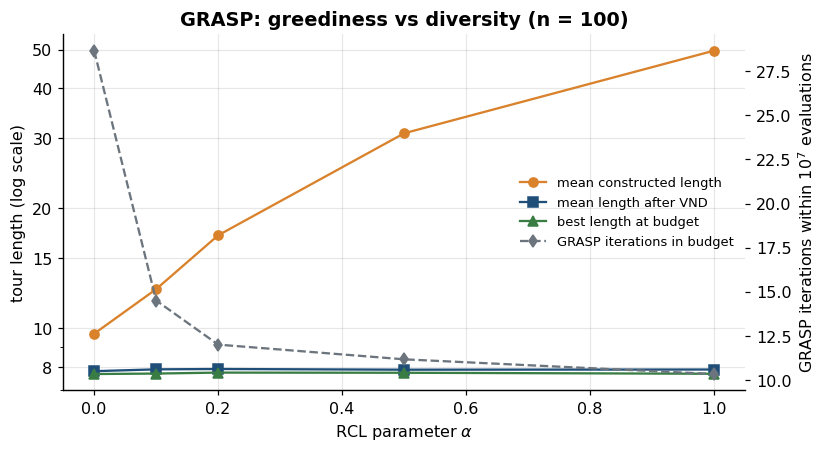

In [10]:
fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.plot(alphas, G_built.mean(1), "o-", color=PALETTE["orange"], label="mean constructed length")
ax1.plot(alphas, G_pol.mean(1), "s-", color=PALETTE["blue"], label="mean length after VND")
ax1.plot(alphas, G_best.mean(1), "^-", color=PALETTE["green"], label="best length at budget")
ax1.set_yscale("log"); ax1.yaxis.set_major_formatter(plt.ScalarFormatter()); ax1.yaxis.set_minor_formatter(plt.NullFormatter())
ax1.set_yticks([8, 10, 15, 20, 30, 40, 50]); ax1.set_xlabel(r"RCL parameter $\alpha$"); ax1.set_ylabel("tour length (log scale)")
ax2 = ax1.twinx()
ax2.plot(alphas, G_it.mean(1), "d--", color=PALETTE["grey"], label="GRASP iterations in budget")
ax2.set_ylabel("GRASP iterations within $10^7$ evaluations"); ax2.grid(False)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center right", fontsize=8.5)
ax1.set_title(r"GRASP: greediness vs diversity (n = 100)")
savefig("w3_grasp_alpha.png"); plt.show()

Note that the RCL parameter is not the only source of diversity: with a random start city, even $\alpha = 0$ yields
up to $n$ distinct nearest-neighbour tours (Exercise 2). That ceiling only binds when the budget allows many more
than $n$ GRASP iterations, which is not the case here; the cheaper descents from greedy tours then buy more
iterations. The printed table is the evidence for the $\alpha$ that is carried forward to Section 7 — but read it
with care: the robust effects are the monotone growth of the constructed length and the fall in the number of
GRASP iterations as $\alpha$ grows; the median best gaps are based on only 6 runs per $\alpha$ and their
differences (about one percentage point, non-monotone in $\alpha$) are of the same size as the run-to-run
spread, so the "tuned" $\alpha$ is a noisy choice. Notice also how little VND cares about where it starts:
the mean length after VND is almost the same for every $\alpha$.

## 7. Equal-budget comparison on $n = 100$

Eight fresh random instances (not used for tuning); each method runs once per instance (seed = instance) with
$10^7$ evaluations: ILS with *better* acceptance and the kick strength $k$ that had the best median in Section 5,
VNS with $k_{max} = 8$ (the largest strength studied), and GRASP with the $\alpha$ that had the best median in
Section 6. We report the ratio to the best
length found on each instance by any of the three, and the convergence curves (median over instances of the
best-so-far ratio). As a scale reference, the Beardwood–Halton–Hammersley asymptotic value
$0.7124\sqrt{nA}$ is printed too; it is a limit for $n \to \infty$, and finite-$n$ optimal tours are longer
because of boundary effects.

In [11]:
t0 = time.time()
grid = np.linspace(2e6, B, 50)
k_best = [1, 2, 4, 8][int(np.argmin(np.median(S_gap[:4], axis=1)))]
a_best = alphas[int(np.argmin(np.median(G_best, axis=1)))]
print(f"tuned settings: ILS k = {k_best}, GRASP alpha = {a_best}")
methods = {"ILS": lambda Dm, g: ils(Dm, B, g, k=k_best), "VNS": lambda Dm, g: vns(Dm, B, g, kmax=8),
           "GRASP": lambda Dm, g: grasp(Dm, B, g, alpha=a_best)}
final = {m: [] for m in methods}; curves = {m: [] for m in methods}
lengths = []
for inst in range(8):
    _, Dm = random_euclidean_tsp(100, np.random.default_rng(2000 + inst))
    runs = {m: fn(Dm, np.random.default_rng(inst)) for m, fn in methods.items()}
    bk = min(at_budget(r, B) for r in runs.values())
    lengths.append(bk)
    for m, r in runs.items():
        final[m].append(at_budget(r, B) / bk)
        curves[m].append(best_so_far_on_grid(r["ev"], r["bs"], grid) / bk)
for m in methods:
    f = np.array(final[m])
    print(f"{m:>6}: median ratio to best {np.median(f):.4f}  IQR [{np.percentile(f, 25):.4f}, {np.percentile(f, 75):.4f}]"
          f"  best on {np.sum(f < 1 + 1e-12)}/8 instances")
for other in ("VNS", "GRASP"):
    wins = int(np.sum(np.array(final["ILS"]) < np.array(final[other])))
    ties = int(np.sum(np.array(final["ILS"]) == np.array(final[other])))
    p_sign = binomtest(wins, 8 - ties, 0.5).pvalue
    print(f"ILS shorter than {other} on {wins}/{8 - ties} untied instances; exact two-sided sign test p = {p_sign:.4f}")
print(f"mean best length {np.mean(lengths):.3f}  vs BHH asymptote {bhh_constant_estimate(100):.3f}"
      f"  ({time.time() - t0:.1f} s)")

tuned settings: ILS k = 8, GRASP alpha = 0.0


   ILS: median ratio to best 1.0000  IQR [1.0000, 1.0000]  best on 8/8 instances
   VNS: median ratio to best 1.0021  IQR [1.0006, 1.0044]  best on 1/8 instances
 GRASP: median ratio to best 1.0036  IQR [1.0015, 1.0069]  best on 1/8 instances
ILS shorter than VNS on 8/8 untied instances; exact two-sided sign test p = 0.0078
ILS shorter than GRASP on 7/8 untied instances; exact two-sided sign test p = 0.0703
mean best length 7.870  vs BHH asymptote 7.124  (32.3 s)


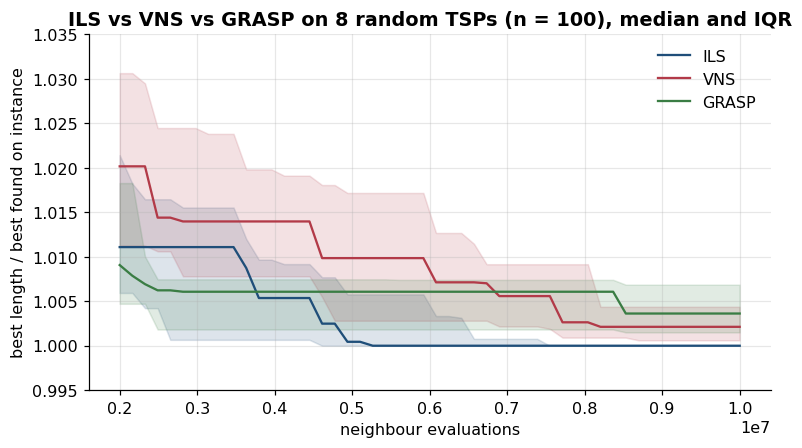

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for m, c in zip(methods, [PALETTE["blue"], PALETTE["red"], PALETTE["green"]]):
    C = np.array(curves[m])
    ax.plot(grid, np.nanmedian(C, 0), color=c, label=m)
    ax.fill_between(grid, np.nanpercentile(C, 25, 0), np.nanpercentile(C, 75, 0), color=c, alpha=0.15)
ax.set_xlabel("neighbour evaluations"); ax.set_ylabel("best length / best found on instance")
ax.set_ylim(0.995, 1.035)
ax.set_title("ILS vs VNS vs GRASP on 8 random TSPs (n = 100), median and IQR")
ax.legend()
savefig("w3_ils_vns_grasp.png"); plt.show()

**Reading the results.** All three methods are built from the same VND, and all three hit the Held–Karp optimum
on small instances, so differences at $n = 100$ come only from *how the next starting point is generated*.
The printed win counts and exact sign tests (8 paired instances, so the smallest attainable two-sided $p$ is
$2/2^8 \approx 0.008$) are the evidence; the effect sizes are small — fractions of a percent of tour length.
Kicks that stay close to the current local optimum (ILS, VNS) re-use its structure; GRASP pays for a full
construction plus a long descent at every iteration. In AI practice, the same three designs appear as
warm-started vs cold-started search: ILS-style perturbation of the incumbent is the core of many
hyperparameter and program-search loops (mutate the best configuration or prompt, re-optimise locally), while
GRASP-style randomised greedy construction is used for feature-subset and schedule initialisation.

## Key takeaways

- ILS, VNS and GRASP are all searches over the set of local optima of a fixed local search; they differ only in
  the generation of the next starting point and in acceptance.
- Vectorised, validated delta evaluation (2-opt, Or-opt) and a VND over both neighbourhoods are the engine; every
  neighbour examined is counted, and comparisons are read off at exactly equal budgets.
- The double bridge $A\,D\,C\,B$ replaces four edges; a kick that is too weak is frequently undone by the local
  search (measured revert rate), a kick that is too strong turns ILS into random restart.
- Acceptance is the intensification/diversification dial of ILS: *better* intensifies, *random walk*
  diversifies, LSMC interpolates.
- GRASP's $\alpha$ trades construction quality against diversity and against the cost of the subsequent descent.

## Exercises

1. ★ Prove that the double bridge $A\,D\,C\,B$ can be written as the composition of two 2-changes that do *not*
   reverse any segment, each of which alone disconnects the tour into two cycles.
2. ★ Show that GRASP with $\alpha = 1$ constructs each of the $(n-1)!$ directed Hamiltonian cycles through a fixed
   start city with equal probability, and that with $\alpha = 0$ (and no ties) it constructs at most $n$ distinct tours.
3. ★★ Implement *don't-look bits* (Bentley 1992) with a candidate list of the 10 nearest neighbours for 2-opt, and
   measure how many evaluations per ILS iteration are saved and whether the final quality at equal budget changes.
4. ★★ Add *path relinking* between the GRASP elite tours (Notebook 2) and compare with plain GRASP at equal budget.
5. ★★ Implement *reactive GRASP* (Prais & Ribeiro 2000): choose $\alpha$ from a finite set with probabilities
   proportional to the average quality it has produced, and compare with the best fixed $\alpha$.
6. ★★★ Use ILS for *prompt or program search*: represent a candidate as a sequence of discrete edits, define a
   local search over single edits and a kick of $k$ random edits, and study the revert rate and the best $k$ on a
   synthetic objective of your design (e.g. matching a hidden target sequence under a noisy score).